# MA-StatDig
## Wavelets 2: Daubechis 1D
### 2025, Version 1.0 (MTN)

Daubechis Wavelets 1D signal
M.Tognolini HEIG-VD 2022  MA-StatDig




### Importation des librairies et Déclaration des fonctions

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
import pywt as wt


---


# Wavelets Filters
The 2-D wavelet transform of a continuous signal $(f(x)$ computes the set of inner products  for scales $ j \in Z $ and position $ n \in Z $.

$\Psi(x)$:
The wavelet atoms are defined by scaling and translating a mother atom 
$ \Psi_{j,n}(x) = \frac{1}{2^j} \Psi(\frac{x - 2^j n}{2^j}    )$

Associated to this oscillating (high pass) wavelet function $\psi$ is a non-oscillating (low pass) scaling function $\phi$.
The fast wavelet transform algorithm does not make use of the wavelet and scaling functions, but of the filters $h$ and $g$ that caracterize their interaction: 

$g[n] = \frac{1}{\sqrt(2)} \langle \Psi(x/2),\Phi(x-n)  \rangle $    $h[n] = \frac{1}{\sqrt(2)} \langle \Phi(x/2),\Phi(x-n)  \rangle $

The simplest filters are the Haar filters 
Daubechies wavelets extends the haar wavelets by using longer filters, that produce smoother scaling functions and wavelets. Furthermore, the larger the size \(p=2k\) of the filter, the higher is the number \(k\) of vanishing moment. 
A high number of vanishing moments allows to better compress regular parts of the signal. However, increasing the number of vanishing moments also inceases the size of the support of the wavelets, wich can be problematic in part where the signal is singular (for instance discontinuous).
Choosing the best wavelet, and thus choosing \(k\), that is adapted to a given class of signals, thus corresponds to a tradeoff between efficiency in regular and singular parts.
The filter with \(k=1\) vanishing moments corresponds to the Haar filter.
The filter with \(k=2\) vanishing moments corresponds to the famous D4 wavelet, which compresses perfectly linear signals.
The filter with \(k=3\) vanishing moments compresses perfectly quadratic signals.
Set the support size. To begin, we select the D4 filter.


In [2]:
p=4
# create low pass filter h and the high pass g . Daubechis wavelet of order 4
w = wt.Wavelet('db2')
print(w)
h = np.array(w.dec_lo)
print(h.shape)
g = np.array(w.dec_hi)
print("h=",h)
print("g=",g)







Wavelet db2
  Family name:    Daubechies
  Short name:     db
  Filters length: 4
  Orthogonal:     True
  Biorthogonal:   True
  Symmetry:       asymmetric
  DWT:            True
  CWT:            False
(4,)
h= [-0.12940952  0.22414387  0.8365163   0.48296291]
g= [-0.48296291  0.8365163  -0.22414387 -0.12940952]


The Haar transform operates over  $J= log_2(N) -1$  scales. It computes a series of coarse scale and fine scale coefficients  $a_j, d_j \in R^N$  where $N_j = 2^j$   

J= 9
f.shape= (1024,)


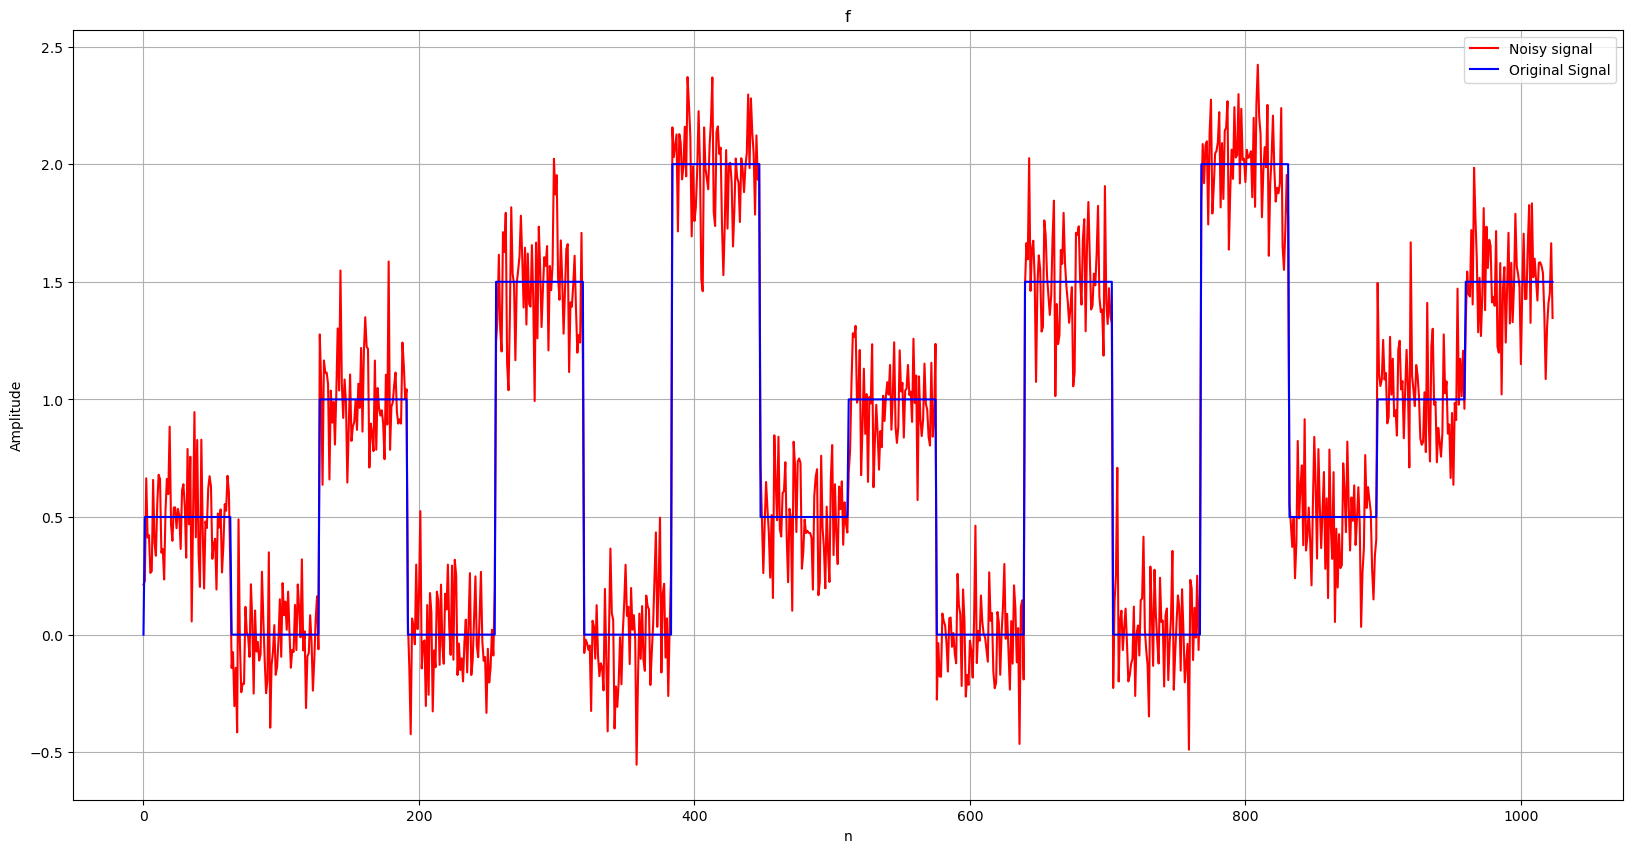

In [3]:

# Signal  definitions
N=1024
J = np.int64(np.log2(N)-1)
print("J=",J)  
# freate a random signal f 
f= np.random.rand(N)
print("f.shape=",f.shape)
#print("f=",f)
signal = 'square'
if signal== 'square':
    x = np.zeros(N)
    x[0] = 0
    x[1:64] = 0.5
    x[128:192] = 1.0
    x[256:320] = 1.5
    x[384:448] = 2.0
    x[448:512] = 0.5
    x[512:576] = 1.0
    x[640:704] = 1.5
    x[768:832] = 2.0
    x[832:896] = 0.5
    x[896:960] = 1.0
    x[960:1024] = 1.5
if signal== 'sinus':
    x1 = np.sin(2*np.pi*0.01*np.arange(np.int16(N/3)))
    x2 = np.sin(2*np.pi*0.03*np.arange(np.int16(N/3)))
    x3 = np.sin(2*np.pi*0.05*np.arange(N-np.int16(N/3)*2))
    x = np.concatenate((x1,x2,x3))

# add gaussian white noise to the signal
NoiseStdDev = 0.2
f= x + NoiseStdDev *np.random.randn(N)

plt.figure()
plt.plot(f,'r',label='Noisy signal')
plt.plot(x,'b',label='Original Signal')
plt.legend()
plt.title('f')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid()
plt.gcf().set_size_inches(20,10)
plt.show()


## Wavelet decomposition
# Daubechis tests

Test Daubechis wavelets decomposition db1  to db6  with  square  signal  ans  nsinus  signal.




J= 8
coefflen= 513


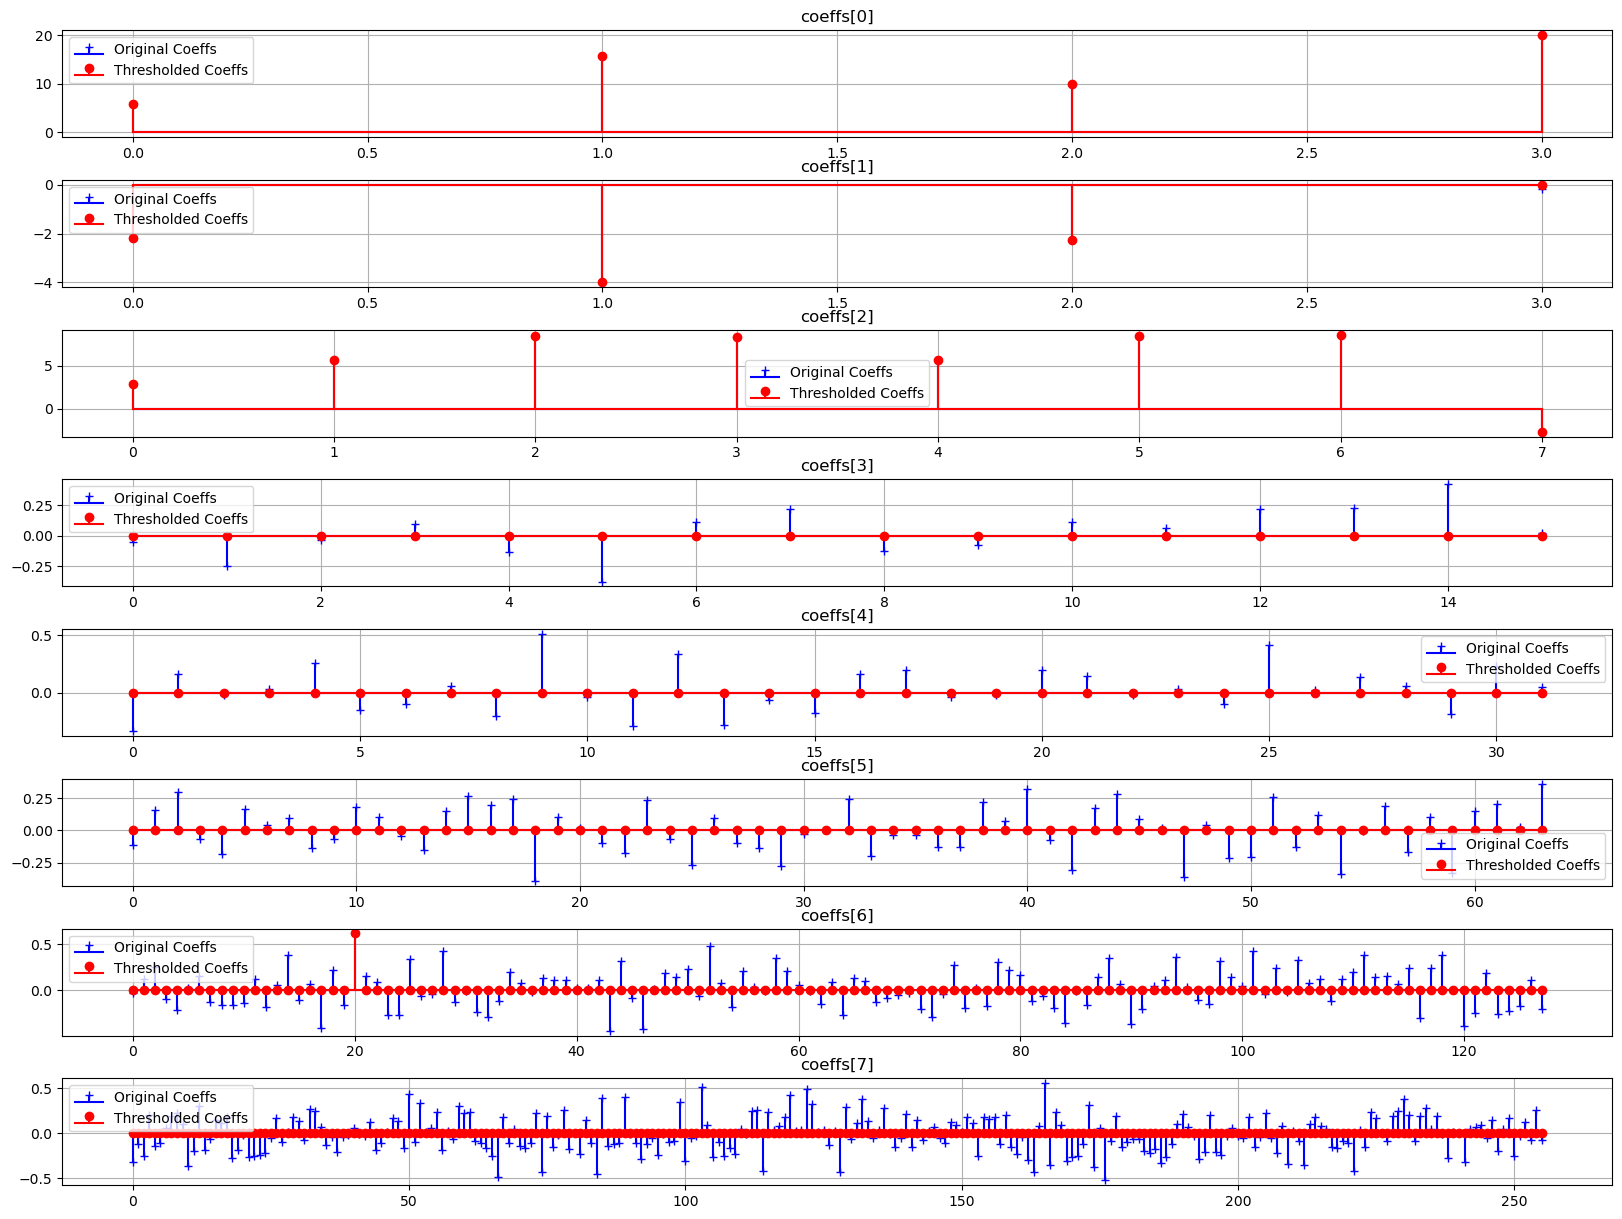

frec.shape= (1024,)
error= 0.005876024033003139


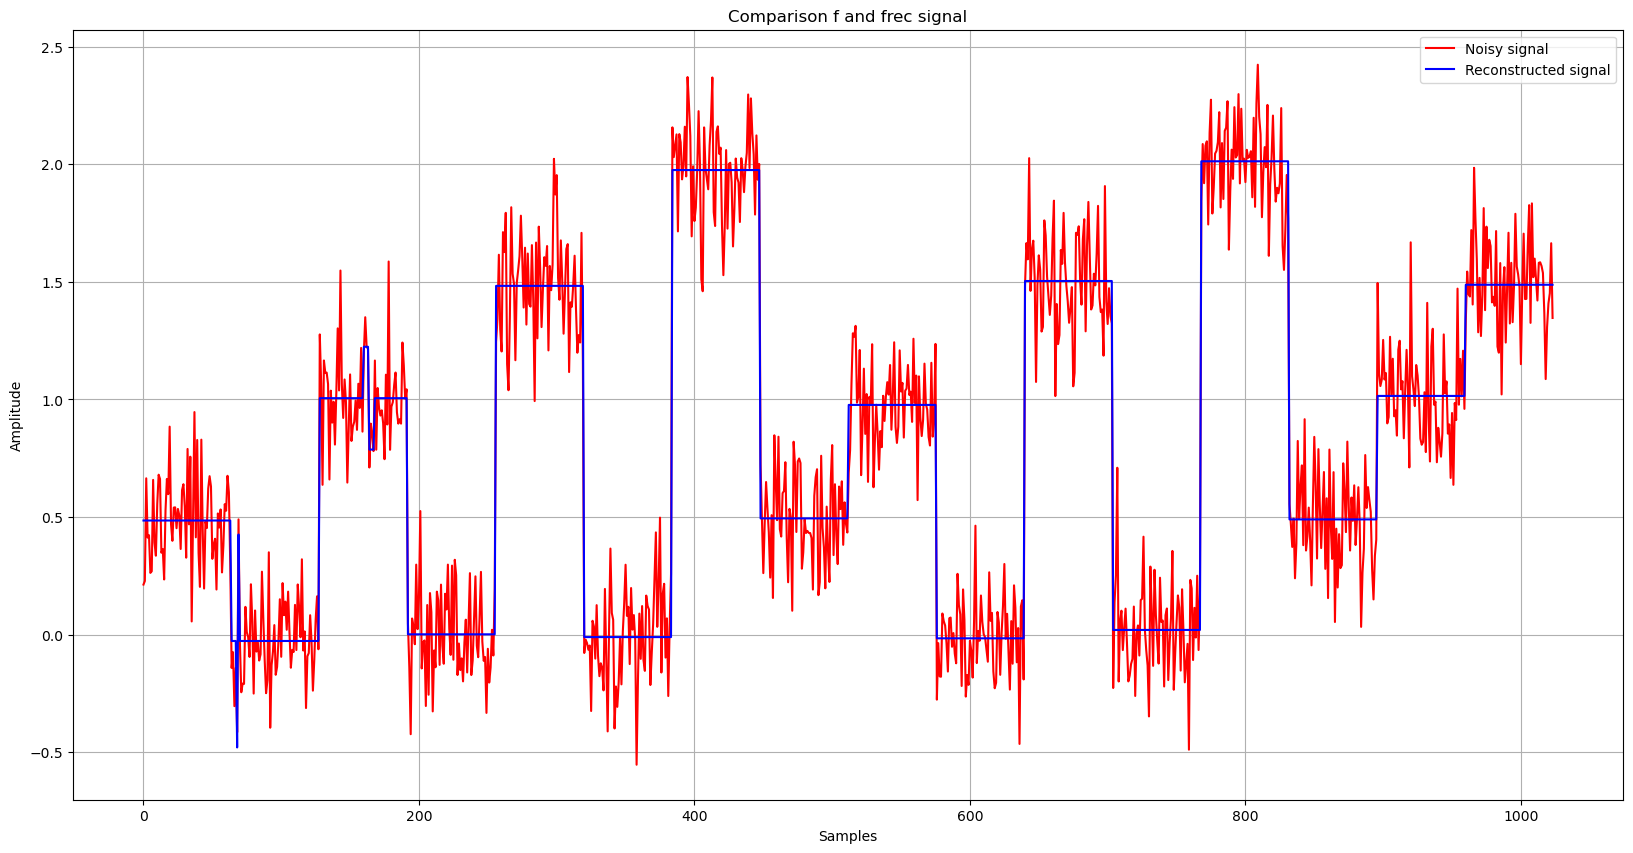

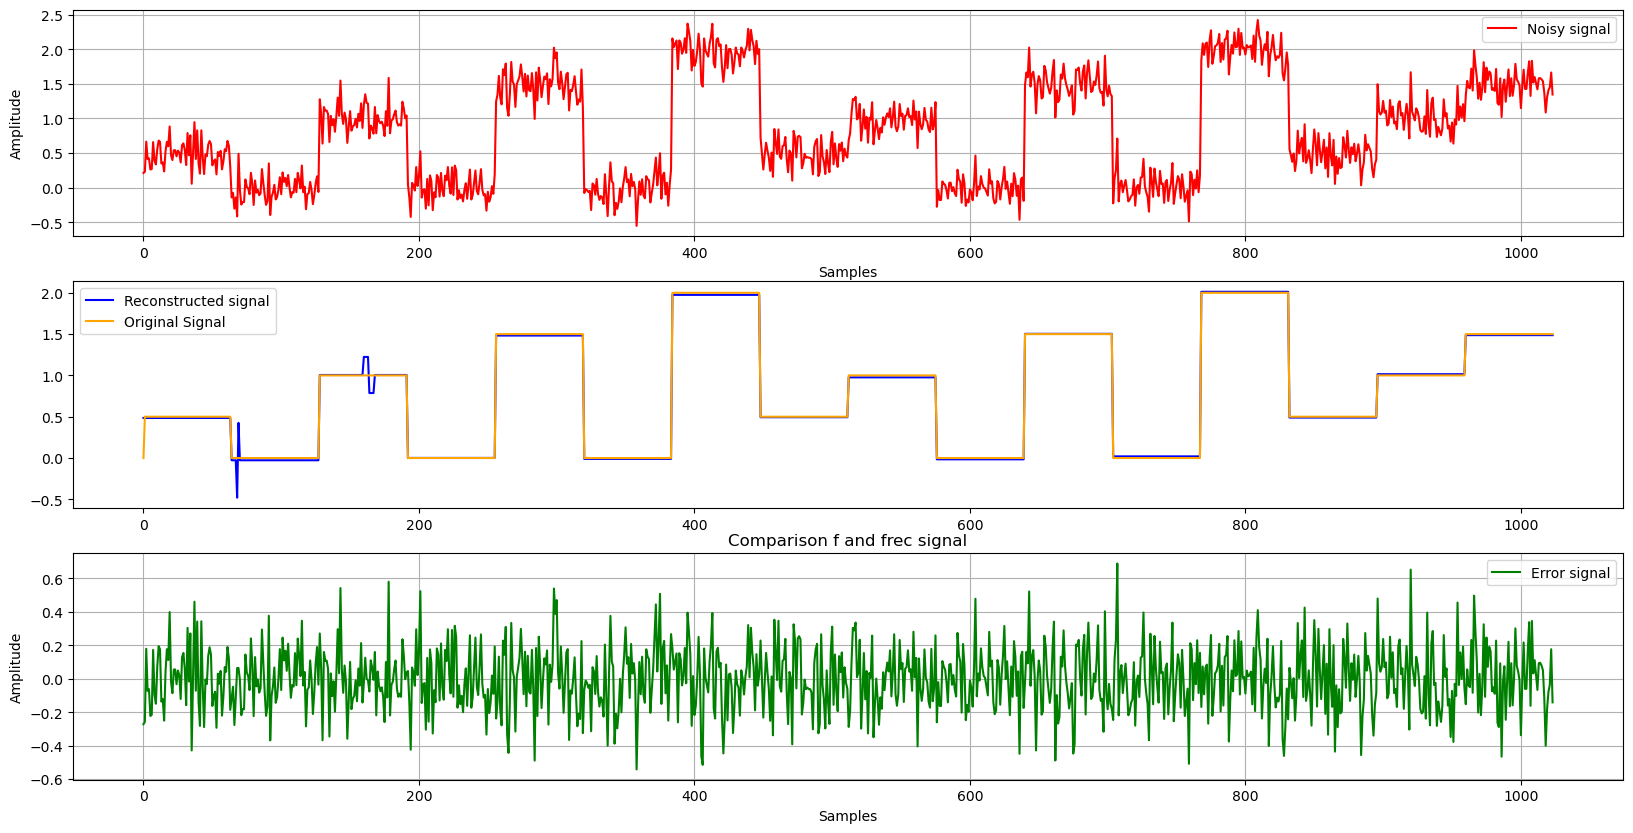

In [ ]:
#The fast wavelet transform algorithm does not make use of the wavelet and scaling functions, but of the filters h and g that caracterize their interaction:




